# 🛒 Shopper Spectrum: Customer Segmentation & Product Recommendations

**Author:** Ronak Jha  
**Domain:** E-Commerce & Retail Analytics  
**Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) | Also on [Kaggle](https://www.kaggle.com/datasets/mathchi/online-retail-ii-data-set-from-ml-repository)

---

## 📌 Project Overview

This notebook walks through a complete end-to-end pipeline for understanding customer purchasing behavior in an online retail store. The goal is twofold:

1. **Customer Segmentation** – Use RFM (Recency, Frequency, Monetary) analysis and KMeans clustering to group customers into meaningful segments (High-Value, Regular, Occasional, At-Risk).
2. **Product Recommendations** – Build a collaborative filtering system using cosine similarity to recommend products a customer might like based on purchase patterns.

The final output feeds into a Streamlit app where a user can:
- Input a product name → get 5 similar product recommendations
- Input RFM values → predict the customer's segment

---

## Table of Contents

1. [Setup & Imports](#1-setup)
2. [Load Dataset](#2-load)
3. [Data Preprocessing](#3-preprocess)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [RFM Feature Engineering](#5-rfm)
6. [Clustering](#6-clustering)
7. [Collaborative Filtering – Recommendation System](#7-reco)
8. [Save Models](#8-save)


---
## 1. Setup & Imports <a id='1-setup'></a>

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

# Serialization
import pickle
import os

# Plot style — keeping it clean and readable
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Load Dataset <a id='2-load'></a>

**Dataset:** UCI Online Retail II  
**Source:** https://archive.ics.uci.edu/dataset/502/online+retail+ii  
**Kaggle Mirror:** https://www.kaggle.com/datasets/mathchi/online-retail-ii-data-set-from-ml-repository

The dataset contains all transactions between 2009–2011 for a UK-based non-store online retail company. It includes ~1 million rows and 8 columns.

To load via `ucimlrepo`:
```python
from ucimlrepo import fetch_ucirepo
online_retail_ii = fetch_ucirepo(id=502)
df = online_retail_ii.data.features
```

Or download the Excel file from Kaggle and load it manually (both sheets merged).

In [11]:
# ── Option A: Load via ucimlrepo (recommended) ──────────────────────────────


# ── Option B: Load from local Excel (downloaded from Kaggle) ─────────────────
# The file is named 'online_retail_II.xlsx' and has two sheets (Year 2009-2010 & 2010-2011)
# Place it in the data/ folder before running this cell.

df = pd.read_excel('online_retail.xlsx')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
# Quick overview
print('=== Dataset Info ===')
df.info()
print('\n=== Null Counts ===')
print(df.isnull().sum())
print('\n=== Basic Stats ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

=== Null Counts ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== Basic Stats ===


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2023-07-04 13:34:57.156387072,4.611114,15287.690570
min,-80995.000000,2022-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2023-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2023-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2023-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2023-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


---
## 3. Data Preprocessing <a id='3-preprocess'></a>

Cleaning steps:
- Drop rows with missing `Customer ID` (can't build RFM without it)
- Remove cancelled invoices (InvoiceNo starts with 'C')
- Remove zero/negative Quantity and Price (invalid transactions)
- Create `TotalPrice = Quantity × Price` for monetary calculations

In [17]:
raw_shape = df.shape
df.dropna(subset=['CustomerID'], inplace=True)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]


df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['CustomerID'].astype(int).astype(str)

# 6. Drop duplicates
df.drop_duplicates(inplace=True)

print(f'Raw shape:    {raw_shape}')
print(f'Clean shape:  {df.shape}')
print(f'Rows removed: {raw_shape[0] - df.shape[0]:,}')
df.head()

Raw shape:    (397884, 8)
Clean shape:  (392692, 10)
Rows removed: 5,192


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Customer ID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,17850
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,17850
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,17850
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,17850
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,17850


---
## 4. Exploratory Data Analysis (EDA) <a id='4-eda'></a>

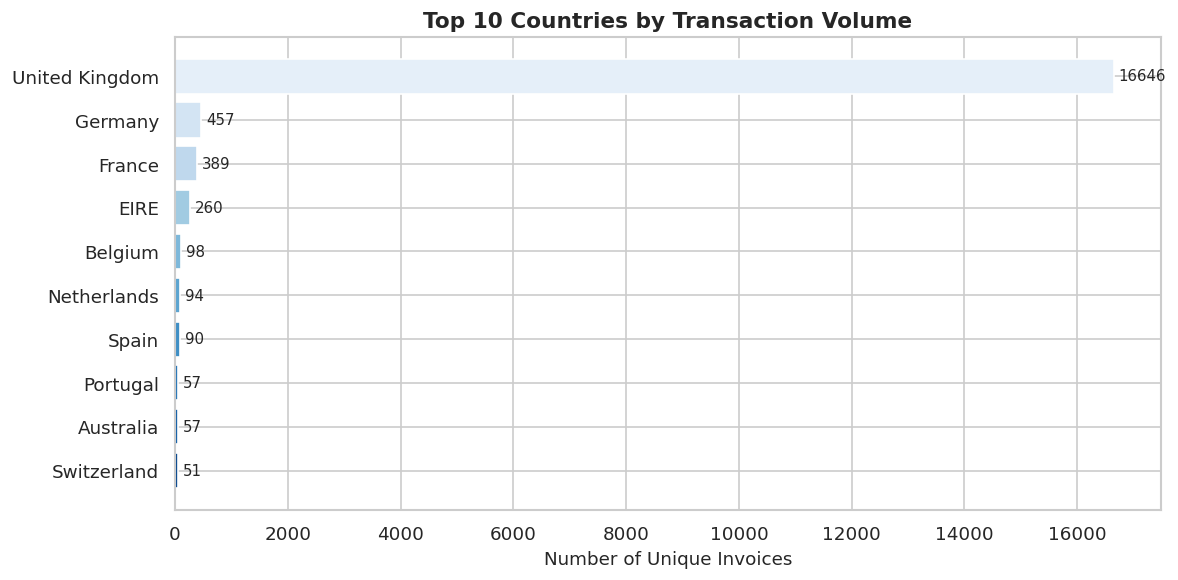

In [20]:
# ── 4.1 Transaction volume by country (top 10) ───────────────────────────────
top_countries = (df.groupby('Country')['InvoiceNo']
                   .nunique()
                   .sort_values(ascending=False)
                   .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=sns.color_palette('Blues_r', 10))
ax.set_xlabel('Number of Unique Invoices', fontsize=11)
ax.set_title('Top 10 Countries by Transaction Volume', fontsize=13, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('eda_countries.png', bbox_inches='tight')
plt.show()

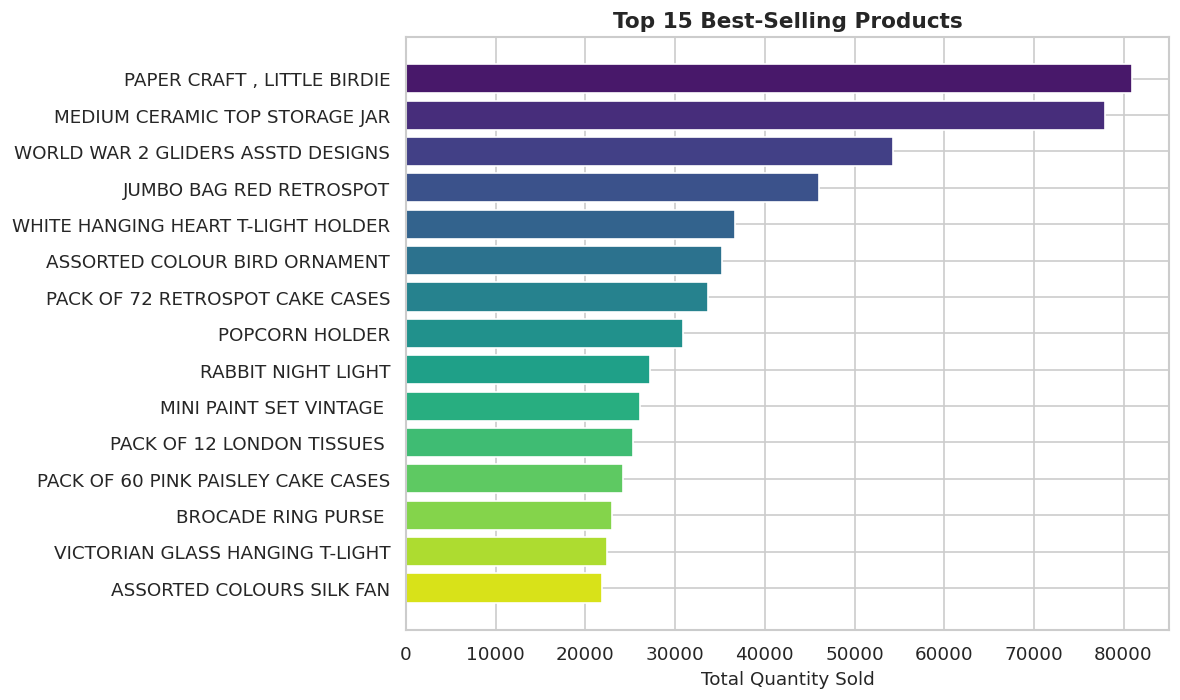

In [21]:
# ── 4.2 Top 15 best-selling products ─────────────────────────────────────────
top_products = (df.groupby('Description')['Quantity']
                  .sum()
                  .sort_values(ascending=False)
                  .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('viridis', 15)
ax.barh(top_products.index[::-1], top_products.values[::-1], color=colors[::-1])
ax.set_xlabel('Total Quantity Sold', fontsize=11)
ax.set_title('Top 15 Best-Selling Products', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_top_products.png', bbox_inches='tight')
plt.show()

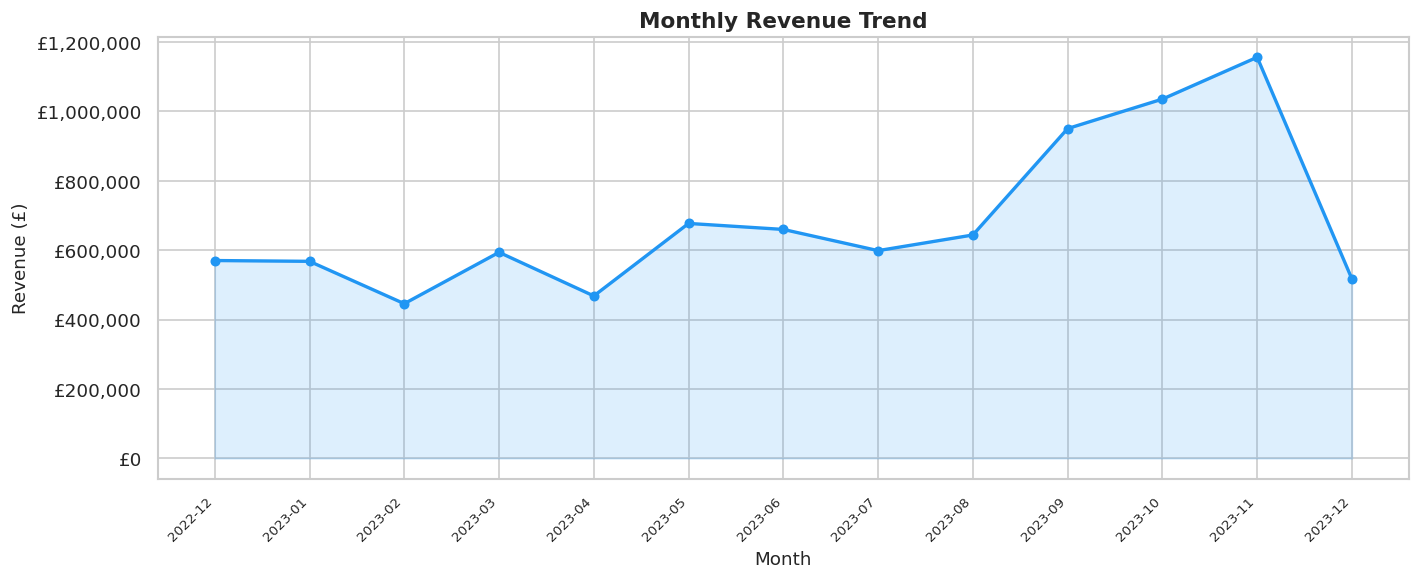

In [22]:
# ── 4.3 Monthly revenue trend ─────────────────────────────────────────────────
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue.index.astype(str), monthly_revenue.values,
        marker='o', linewidth=2, color='#2196F3', markersize=5)
ax.fill_between(monthly_revenue.index.astype(str), monthly_revenue.values,
                alpha=0.15, color='#2196F3')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (£)', fontsize=11)
ax.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('eda_monthly_revenue.png', bbox_inches='tight')
plt.show()

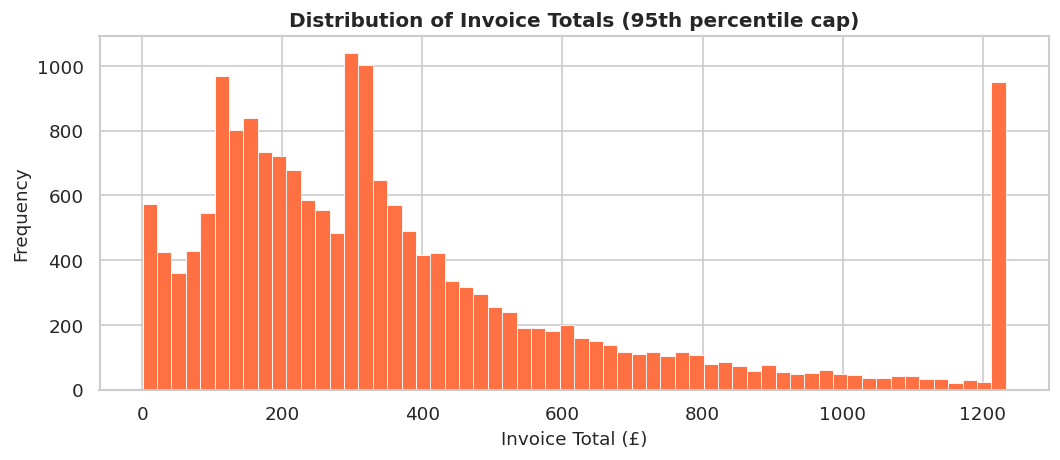

In [24]:
# ── 4.4 Distribution of spend per transaction ────────────────────────────────
invoice_totals = df.groupby('InvoiceNo')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(invoice_totals.clip(upper=invoice_totals.quantile(0.95)),
        bins=60, color='#FF7043', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Invoice Total (£)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Invoice Totals (95th percentile cap)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_invoice_dist.png', bbox_inches='tight')
plt.show()

---
## 5. RFM Feature Engineering <a id='5-rfm'></a>

**RFM** is a customer analytics framework:
- **Recency (R):** How recently did the customer make a purchase?
- **Frequency (F):** How many times have they purchased?
- **Monetary (M):** How much have they spent in total?

These three features let us characterize each customer's behavior in a compact numeric form.

In [25]:
# Reference date = one day after the latest transaction in the dataset
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(f'RFM table shape: {rfm.shape}')
rfm.head(10)

Snapshot date: 2023-12-10
RFM table shape: (4338, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [26]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


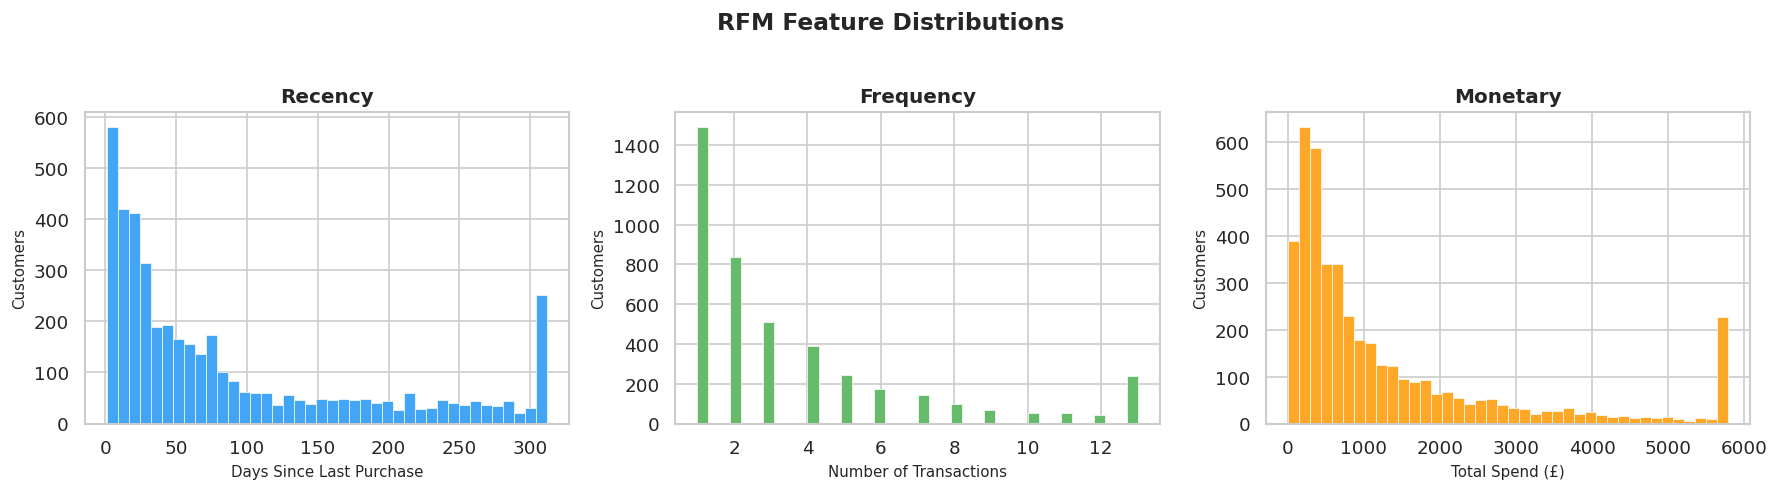

In [28]:
# ── 5.1 RFM distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['Recency', 'Frequency', 'Monetary']
colors  = ['#42A5F5', '#66BB6A', '#FFA726']
labels  = ['Days Since Last Purchase', 'Number of Transactions', 'Total Spend (£)']

for ax, col, clr, lbl in zip(axes, metrics, colors, labels):
    # Cap at 95th percentile to avoid outlier distortion
    data = rfm[col].clip(upper=rfm[col].quantile(0.95))
    ax.hist(data, bins=40, color=clr, edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(lbl, fontsize=9)
    ax.set_ylabel('Customers', fontsize=9)

fig.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_distributions.png', bbox_inches='tight')
plt.show()

---
## 6. Clustering (KMeans + RFM) <a id='6-clustering'></a>

In [29]:
# ── 6.1 Normalized RFM values ─────────────────────────────────────────────────
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print('Scaled shape:', rfm_scaled.shape)
print('Mean (should be ~0):', rfm_scaled.mean(axis=0).round(4))
print('Std  (should be ~1):', rfm_scaled.std(axis=0).round(4))

Scaled shape: (4338, 3)
Mean (should be ~0): [0. 0. 0.]
Std  (should be ~1): [1. 1. 1.]


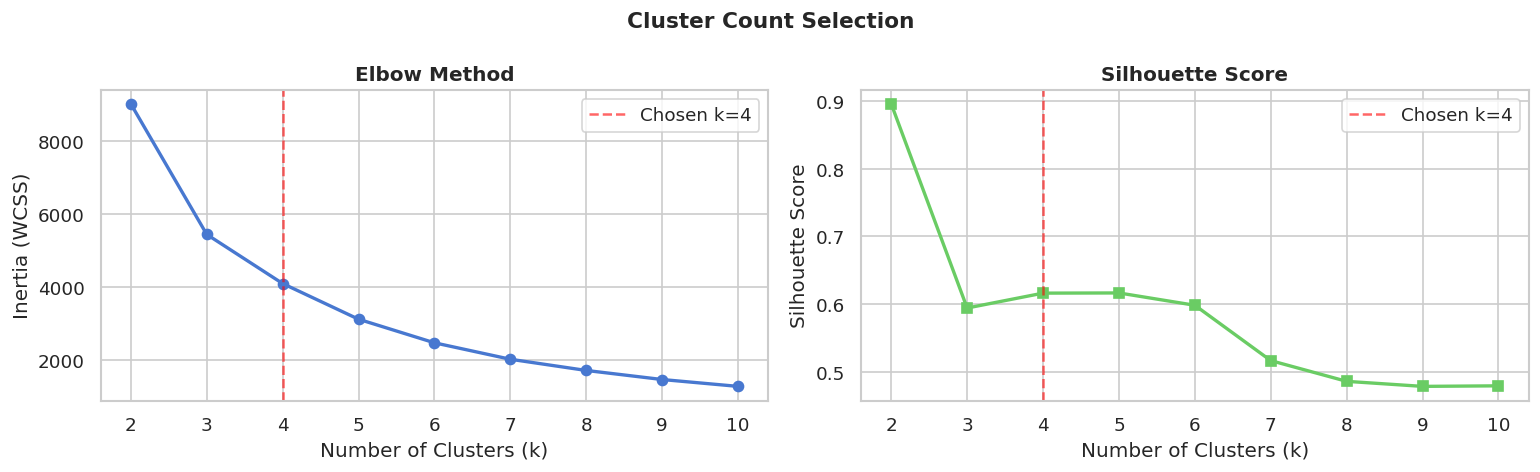

Best Silhouette Score: 0.8958 at k=2


In [31]:
# ── 6.2 Elbow Method ─────────────────────────────────────────────────────────
inertia_vals  = []
silhouette_vals = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(rfm_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
ax1.plot(k_range, inertia_vals, 'bo-', linewidth=2, markersize=6)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='Chosen k=4')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method', fontweight='bold')
ax1.legend()

# Silhouette
ax2.plot(k_range, silhouette_vals, 'gs-', linewidth=2, markersize=6)
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='Chosen k=4')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.legend()

plt.suptitle('Cluster Count Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()

print(f'Best Silhouette Score: {max(silhouette_vals):.4f} at k={list(k_range)[silhouette_vals.index(max(silhouette_vals))]}')

In [32]:
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, init='k-means++', n_init=15, random_state=42)
kmeans.fit(rfm_scaled)

rfm['Cluster'] = kmeans.labels_

final_silhouette = silhouette_score(rfm_scaled, kmeans.labels_)
print(f'Final Model — Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {final_silhouette:.4f}')

Final Model — Inertia: 4096.30 | Silhouette Score: 0.6162


In [33]:
# ── 6.4 Interpret and label clusters ──────────────────────────────────────────
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print(cluster_summary)

# Label clusters based on their RFM averages:
#  - Low Recency + High Freq + High Monetary  → High-Value
#  - Medium values across board               → Regular
#  - Low Freq + Low Monetary                  → Occasional
#  - High Recency (haven't bought lately)     → At-Risk

# Rank clusters by composite score to assign labels programmatically
cluster_summary['Score'] = (
    -cluster_summary['Recency']   # lower recency is better
    + cluster_summary['Frequency'] * 10
    + cluster_summary['Monetary'] * 0.01
)

sorted_clusters = cluster_summary['Score'].sort_values(ascending=False).index.tolist()
label_map = {
    sorted_clusters[0]: 'High-Value',
    sorted_clusters[1]: 'Regular',
    sorted_clusters[2]: 'Occasional',
    sorted_clusters[3]: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(label_map)
print('\nCluster → Segment mapping:')
print(label_map)

         Recency  Frequency  Monetary
Cluster                              
0           43.7        3.7    1353.6
1          248.1        1.6     478.8
2            7.4       82.5  127188.0
3           15.5       22.3   12690.5

Cluster → Segment mapping:
{2: 'High-Value', 3: 'Regular', 0: 'Occasional', 1: 'At-Risk'}


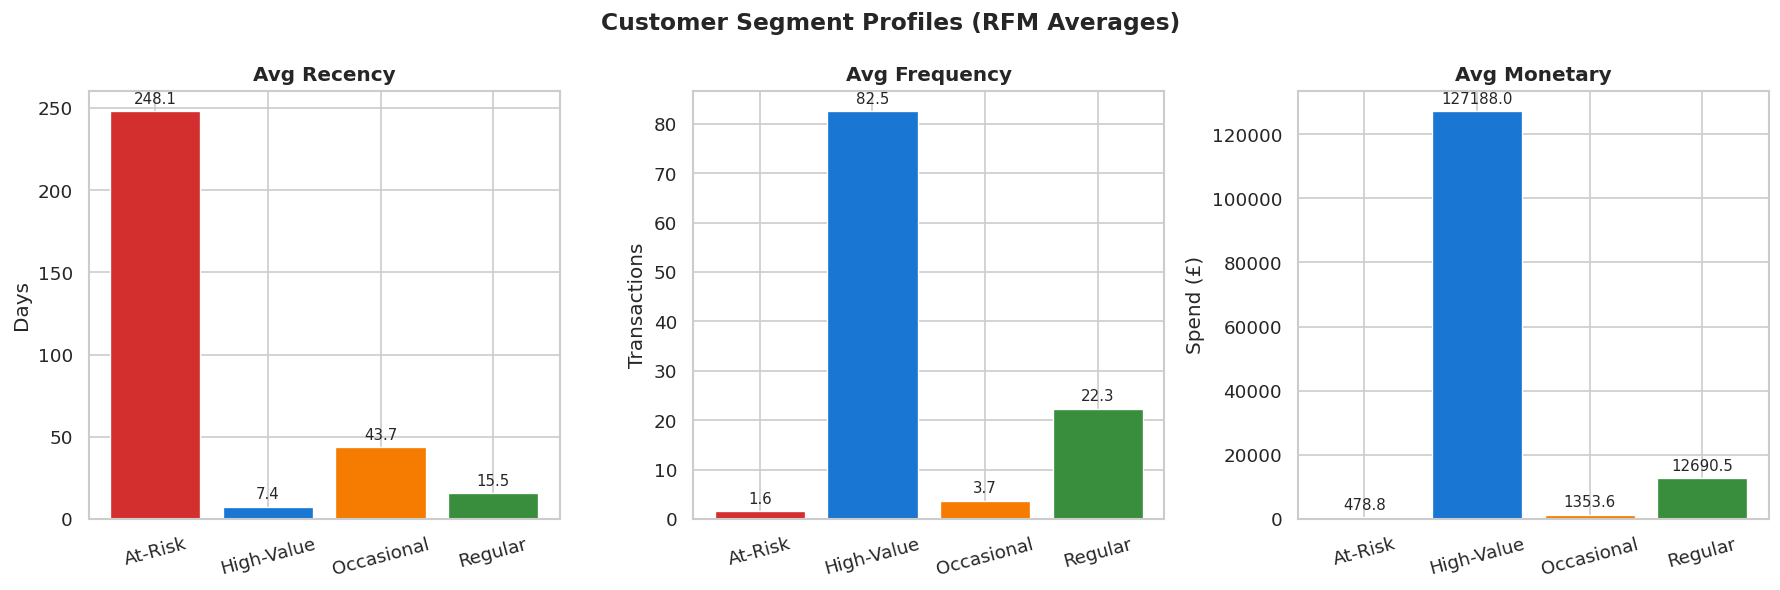

In [35]:
# ── 6.5 Cluster profile visualization ────────────────────────────────────────
segment_stats = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
segment_colors = {'High-Value': '#1976D2', 'Regular': '#388E3C',
                  'Occasional': '#F57C00', 'At-Risk': '#D32F2F'}
metrics = ['Recency', 'Frequency', 'Monetary']
ylabels = ['Days', 'Transactions', 'Spend (£)']

for ax, m, yl in zip(axes, metrics, ylabels):
    vals  = segment_stats[m]
    clrs  = [segment_colors[s] for s in vals.index]
    bars  = ax.bar(vals.index, vals.values, color=clrs, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Avg {m}', fontweight='bold')
    ax.set_ylabel(yl)
    ax.set_xlabel('')
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Customer Segment Profiles (RFM Averages)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_profiles.png', bbox_inches='tight')
plt.show()

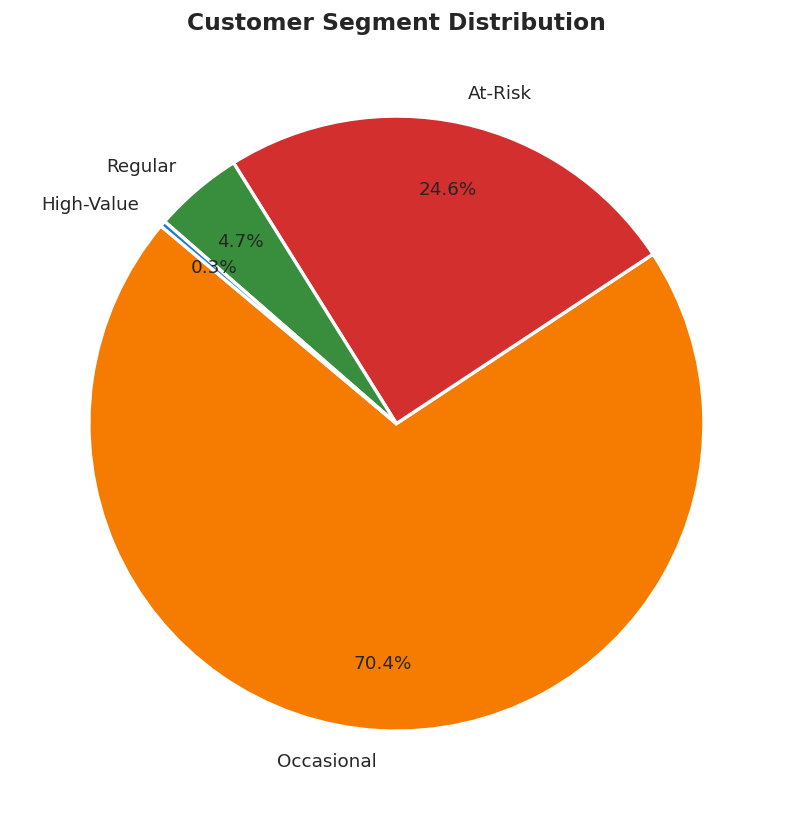

In [37]:
# ── 6.6 Segment size ──────────────────────────────────────────────────────────
seg_counts = rfm['Segment'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
clrs = [segment_colors[s] for s in seg_counts.index]
wedges, texts, autotexts = ax.pie(
    seg_counts.values,
    labels=seg_counts.index,
    colors=clrs,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(linewidth=2, edgecolor='white')
)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_pie.png', bbox_inches='tight')
plt.show()

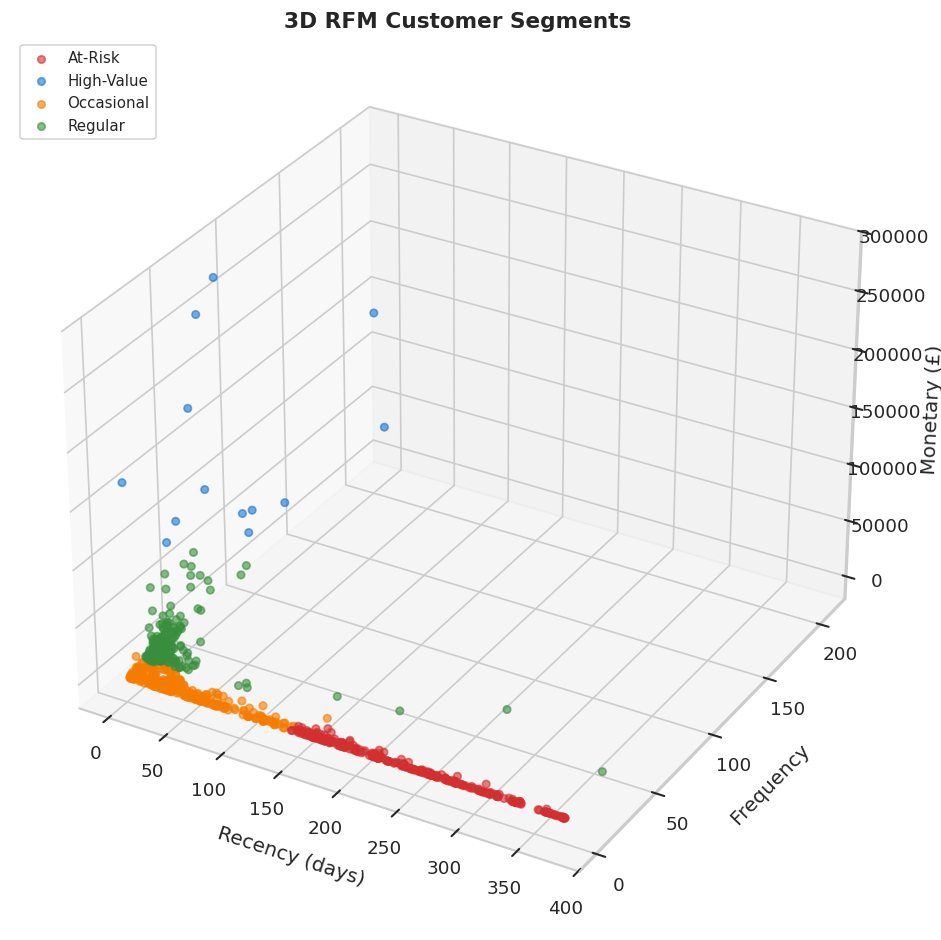

In [39]:
# ── 6.7 3D Scatter of RFM clusters ───────────────────────────────────────────
fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')

for seg, grp in rfm.groupby('Segment'):
    sample = grp.sample(min(len(grp), 300), random_state=42)  # cap for clarity
    ax.scatter(
        sample['Recency'], sample['Frequency'], sample['Monetary'],
        label=seg, color=segment_colors[seg], alpha=0.6, s=20
    )

ax.set_xlabel('Recency (days)', labelpad=8)
ax.set_ylabel('Frequency', labelpad=8)
ax.set_zlabel('Monetary (£)', labelpad=8)
ax.set_title('3D RFM Customer Segments', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('rfm_3d_scatter.png', bbox_inches='tight')
plt.show()

---
## 7. Collaborative Filtering – Product Recommendation System <a id='7-reco'></a>

**Approach:** Item-based Collaborative Filtering using Cosine Similarity

Steps:
1. Build a **Customer × Product** purchase matrix (pivot table)
2. Compute **cosine similarity** between every pair of products
3. For any given product, return the top-5 most similar products

In [41]:
# ── 7.1 Build Customer-Product matrix ────────────────────────────────────────
df_uk = df[df['Country'] == 'United Kingdom'].copy()

# Remove descriptions that are likely non-product entries
non_product = ['POSTAGE', 'DOTCOM POSTAGE', 'BANK CHARGES', 'MANUAL', 'AMAZON FEE']
df_uk = df_uk[~df_uk['Description'].str.upper().isin(non_product)]

# only products that appear in at least 10 transactions (reduces matrix sparsity)
product_counts = df_uk['Description'].value_counts()
popular_products = product_counts[product_counts >= 10].index
df_uk = df_uk[df_uk['Description'].isin(popular_products)]

# pivot: rows = customers, columns = products, values = quantity purchased
basket = df_uk.pivot_table(
    index='Customer ID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print(f'Customer-Product matrix shape: {basket.shape}')
print(f'Sparsity: {(basket == 0).values.mean() * 100:.1f}%')

Customer-Product matrix shape: (3913, 2887)
Sparsity: 97.9%


In [42]:
# ── 7.2 Compute Item-Item Cosine Similarity ────────────────────────────────── 
# Transpose so products are rows
item_matrix = basket.T  # shape: (products, customers)

cos_sim = cosine_similarity(item_matrix)
similarity_df = pd.DataFrame(
    cos_sim,
    index=item_matrix.index,
    columns=item_matrix.index
)

print(f'Similarity matrix shape: {similarity_df.shape}')
similarity_df.iloc[:5, :5]

Similarity matrix shape: (2887, 2887)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY
Description,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000245,0.000808,0.000000
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.012674,0.014189,0.000000
DOLLY GIRL BEAKER,0.000245,0.012674,1.000000,0.104158,0.000000
I LOVE LONDON MINI BACKPACK,0.000808,0.014189,0.104158,1.000000,0.033487
NINE DRAWER OFFICE TIDY,0.000000,0.000000,0.000000,0.033487,1.000000


In [43]:
# ── 7.3 Recommendation function ───────────────────────────────────────────────
def get_recommendations(product_name: str, top_n: int = 5) -> list:
    """
    Returns the top_n most similar products for a given product_name.
    Performs a case-insensitive partial match if exact name not found.
    """
    product_name_upper = product_name.upper().strip()
    
    # Try exact match first
    if product_name_upper in similarity_df.index:
        query = product_name_upper
    else:
        # Partial match
        matches = [p for p in similarity_df.index if product_name_upper in p]
        if not matches:
            return []
        query = matches[0]  # take best match
    
    similar = (
        similarity_df[query]
        .drop(query)                     # exclude the product itself
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )
    return similar

test_product = 'WHITE HANGING HEART T-LIGHT HOLDER'
recs = get_recommendations(test_product)
print(f'Recommendations for "{test_product}":')
for i, r in enumerate(recs, 1):
    print(f'  {i}. {r}')

Recommendations for "WHITE HANGING HEART T-LIGHT HOLDER":
  1. GIN + TONIC DIET METAL SIGN
  2. RED HANGING HEART T-LIGHT HOLDER
  3. WASHROOM METAL SIGN
  4. LAUNDRY 15C METAL SIGN
  5. GREEN VINTAGE SPOT BEAKER


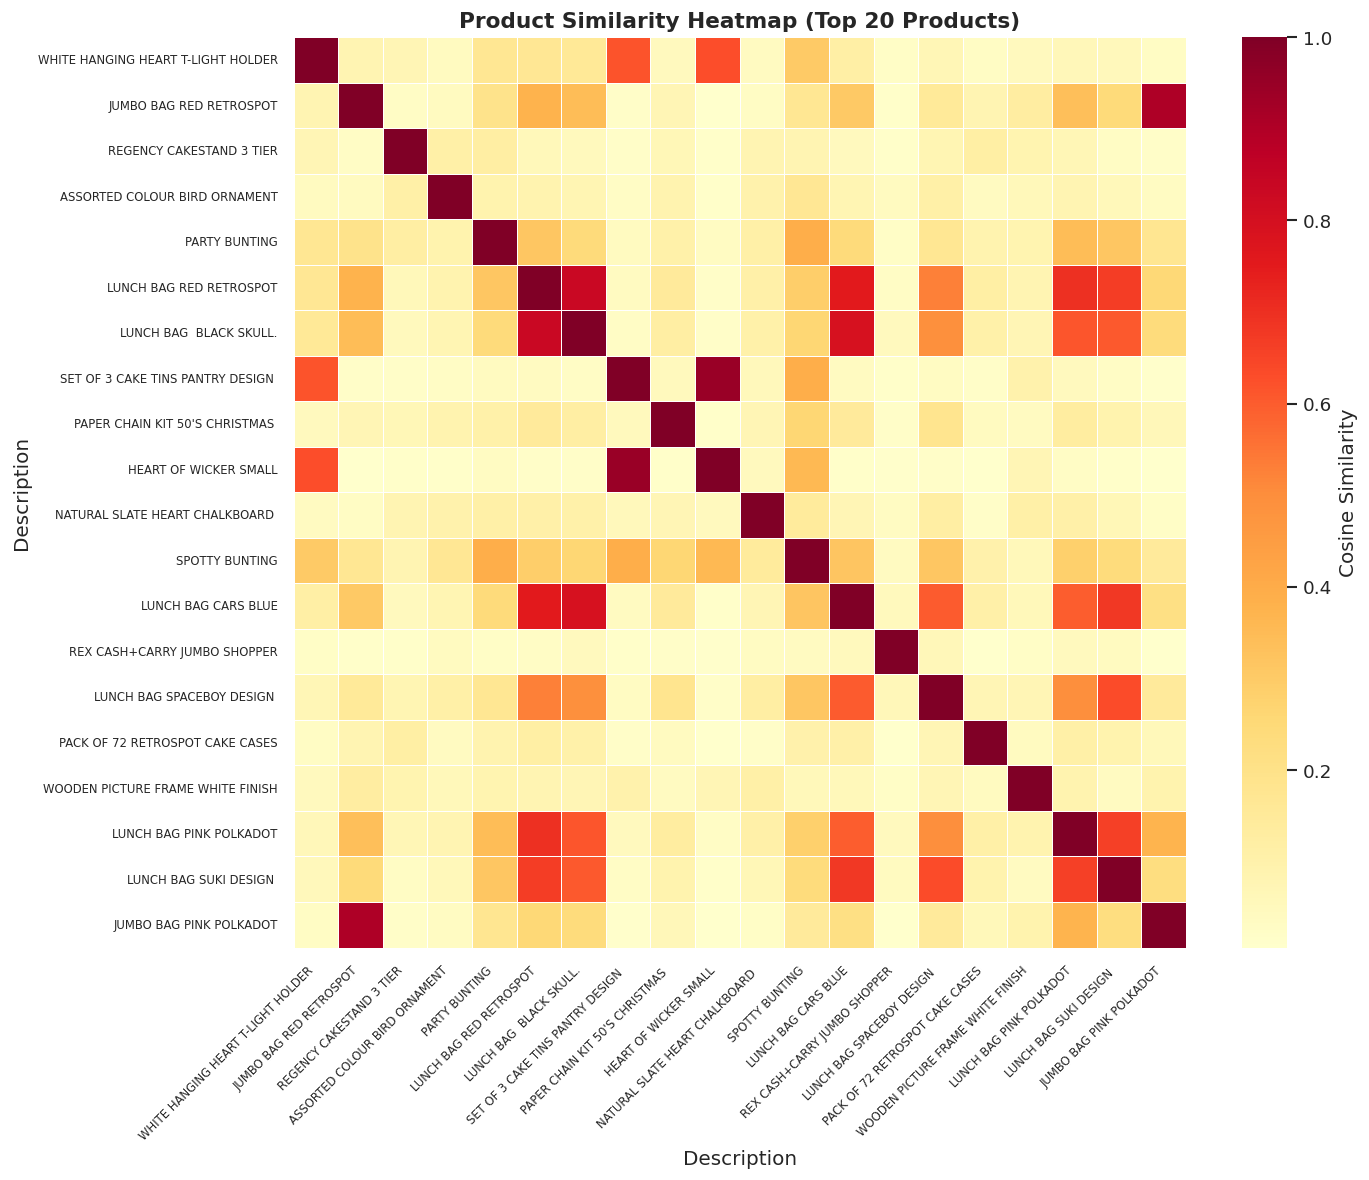

In [45]:
# ── 7.4 Heatmap of similarity (top 20 products) ───────────────────────────────
top20 = product_counts.head(20).index
sim_subset = similarity_df.loc[top20, top20]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    sim_subset,
    annot=False,
    cmap='YlOrRd',
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Cosine Similarity'}
)
ax.set_title('Product Similarity Heatmap (Top 20 Products)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', bbox_inches='tight')
plt.show()

---
## 8. Save Models & Artifacts <a id='8-save'></a>

In [47]:
os.makedirs('models', exist_ok=True)

# Save KMeans model
with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save StandardScaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save cluster label mapping
with open('models/label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

# Save similarity matrix
similarity_df.to_pickle('models/similarity_matrix.pkl')

# Save product list (for autocomplete in Streamlit)
product_list = similarity_df.index.tolist()
with open('models/product_list.pkl', 'wb') as f:
    pickle.dump(product_list, f)

print('All model artifacts saved to /models/')
print('  → kmeans_model.pkl')
print('  → scaler.pkl')
print('  → label_map.pkl')
print('  → similarity_matrix.pkl')
print('  → product_list.pkl')

All model artifacts saved to /models/
  → kmeans_model.pkl
  → scaler.pkl
  → label_map.pkl
  → similarity_matrix.pkl
  → product_list.pkl


In [49]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print(f'Total transactions (cleaned): {df.shape[0]:,}')
print(f'Unique customers:             {rfm.shape[0]:,}')
print(f'Unique products (UK):         {basket.shape[1]:,}')
print(f'KMeans Silhouette Score:      {final_silhouette:.4f}')
print(f'KMeans Inertia:               {kmeans.inertia_:.2f}')
print('\nSegment Breakdown:')
for seg, cnt in rfm['Segment'].value_counts().items():
    pct = cnt / rfm.shape[0] * 100
    print(f'  {seg:<12}: {cnt:>5} customers ({pct:.1f}%)')

Total transactions (cleaned): 392,692
Unique customers:             4,338
Unique products (UK):         2,887
KMeans Silhouette Score:      0.6162
KMeans Inertia:               4096.30

Segment Breakdown:
  Occasional  :  3054 customers (70.4%)
  At-Risk     :  1067 customers (24.6%)
  Regular     :   204 customers (4.7%)
  High-Value  :    13 customers (0.3%)
